# Lid-driven cavity flow

## Import Library

In [411]:
import numpy as np
import matplotlib.pyplot as plt

## Domain Setup

In [412]:
L = 1.0  # Length of the cavity
N = 41   # Number of grid points

dx = 0.025  # Grid spacing
dy = 0.025

Re = 100.0  # Reynolds number
U_lid = 1.0  # Lid velocity

Nu = U_lid * L / Re  # Kinematic viscosity

# Initial velocity and pressure fields
u = np.zeros((N, N)) 
v = np.zeros((N, N))
p = np.zeros((N, N))

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

safety_factor = 0.8

dt = safety_factor / (U_lid/dx + U_lid/dy + 4*Nu/dx**2)

CFL_x = U_lid * dt / dx
CFL_y = U_lid * dt / dy
r = Nu * dt / dx**2

print(f"dt       = {dt:.6f}")
print(f"CFL_x    = {CFL_x:.4f}")
print(f"CFL_y    = {CFL_y:.4f}")
print(f"r        = {r:.4f}")
print(f"Combined = {CFL_x + CFL_y + 4*r:.4f}  (must be ≤ 1)")

nt = 20000  # Number of time steps
T = nt * dt  # Total simulation time
print(f"Total simulation time T = {T:.4f}")

dt       = 0.005556
CFL_x    = 0.2222
CFL_y    = 0.2222
r        = 0.0889
Combined = 0.8000  (must be ≤ 1)
Total simulation time T = 111.1111


## Algorithm Per Time Step

## Apply boundary conditions to u, v

In [413]:
def apply_boundary_conditions(u, v):
    # Top lid — moves right at U_lid, no vertical velocity
    u[-1, :] = U_lid
    v[-1, :] = 0.0

    # bottom
    u[0,:]=0.0
    v[0,:]=0.0
    
    # left
    u[:,0]=0.0
    v[:,0]=0.0

    # right
    u[:,-1]=0.0
    v[:,-1]=0.0

    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [414]:
def momentum_predictor(u, v, p, dx, dy, dt, Nu):
    un = u.copy()
    vn = v.copy()

    u_star = un.copy()
    v_star = vn.copy()

    # Neighbours of u, v - interior points only
    u_e = un[1:-1, 2:]   # u[i, j+1]
    u_w = un[1:-1, :-2]  # u[i, j-1]
    u_n = un[2:, 1:-1]   # u[i+1, j]
    u_s = un[:-2, 1:-1]  # u[i-1, j]

    v_e = vn[1:-1, 2:]   # v[i, j+1]
    v_w = vn[1:-1, :-2]  # v[i, j-1]
    v_n = vn[2:, 1:-1]   # v[i+1, j]
    v_s = vn[:-2, 1:-1]  # v[i-1, j]

    # Convection terms - Upwind scheme
    conv_u_x = np.maximum(un[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (u_e - un[1:-1, 1:-1])/dx
    conv_u_y = np.maximum(vn[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (u_n - un[1:-1, 1:-1])/dy
    
    conv_v_x = np.maximum(un[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (v_e - vn[1:-1, 1:-1])/dx
    conv_v_y = np.maximum(vn[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (v_n - vn[1:-1, 1:-1])/dy

    conv_u = conv_u_x + conv_u_y
    conv_v = conv_v_x + conv_v_y

    # Diffusion terms (central differences)
    diff_u = Nu * (u_e - 2*un[1:-1, 1:-1] + u_w) / dx**2 + Nu * (u_n - 2*un[1:-1, 1:-1] + u_s) / dy**2
    diff_v = Nu * (v_n - 2*vn[1:-1, 1:-1] + v_s) / dy**2 + Nu * (v_e - 2*vn[1:-1, 1:-1] + v_w) / dx**2

    u_star[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (diff_u - conv_u)
    v_star[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (diff_v - conv_v)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [415]:
# compute the divergence of the intermediate velocity field
def compute_divergence(u_star, v_star, dx, dy):
    div = (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx) + (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2*dy)
    return div

## Connector - Pressure Poisson Solver

In [416]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy, dt, rho=1.0, max_iter=20000, tol=1e-4):
    # Solve the Poisson equation iteratively
    for it in range(max_iter):
        p_old = p.copy()

        # Neighbours of p - interior points only
        p_e = p_old[1:-1, 2:]   # p[i, j+1]
        p_w = p_old[1:-1, :-2]  # p[i, j-1]
        p_n = p_old[2:, 1:-1]   # p[i+1, j]
        p_s = p_old[:-2, 1:-1]  # p[i-1, j]

        div = compute_divergence(u_star, v_star, dx, dy)

        rhs = (rho / dt) * div

        # Jacobi update for pressure
        p[1:-1, 1:-1] = (p_e + p_w) * dy**2 + (p_n + p_s) * dx**2 - rhs * dx**2 * dy**2
        p[1:-1, 1:-1] /= (2 * (dx**2 + dy**2))

        # Boundary conditions for pressure (Neumann: dp/dn=0)
        p[0, :] = p[1, :]     # dp/dy=0 at bottom
        p[-1, :] = p[-2, :]   # dp/dy=0 at top
        p[:, 0] = p[:, 1]     # dp/dx=0 at left
        p[:, -1] = p[:, -2]   # dp/dx=0 at right

        p[1, 1] = 0.0  # Reference pressure point to avoid singularity

        # Check for convergence
        if np.linalg.norm(p - p_old) < tol:
            break
    else:
        print("Pressure Poisson did not converge within the maximum iterations.")
    
    return p

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [417]:
def velocity_corrector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    # Neighbours of p - interior points only
    p_e = p[1:-1, 2:]   # p[i, j+1]
    p_w = p[1:-1, :-2]  # p[i, j-1]
    p_n = p[2:, 1:-1]   # p[i+1, j]
    p_s = p[:-2, 1:-1]  # p[i-1, j]

    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - (dt/rho) * (p_e - p_w) / (2*dx)
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - (dt/rho) * (p_n - p_s) / (2*dy)

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [418]:
def check_convergence(u, v, u_old, v_old, tol=1e-4):
    du = np.linalg.norm(u - u_old)
    dv = np.linalg.norm(v - v_old)
    return du < tol and dv < tol

## Main Loop

In [419]:
residual_history = []

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_old, v_old = apply_boundary_conditions(u_old, v_old)
    u_star, v_star = momentum_predictor(u_old, v_old, p_old, dx, dy, dt, Nu)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy, dt)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy, dt)

    u, v = apply_boundary_conditions(u, v)

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)
    if n % 100 == 0:
        print(f"Step {n:4d} | residual = {residual:.2e}")
        
    if check_convergence(u, v, u_old, v_old):
        print(f"Converged at step {n}.")
        break

else:    print("Did not converge within the maximum time steps.")

Step    0 | residual = 8.66e-02
Step  100 | residual = 1.94e-03
Step  200 | residual = 7.76e-04
Step  300 | residual = 4.05e-04
Step  400 | residual = 2.42e-04
Step  500 | residual = 1.55e-04
Step  600 | residual = 1.04e-04
Step  700 | residual = 7.10e-05
Step  800 | residual = 4.95e-05
Step  900 | residual = 3.48e-05
Step 1000 | residual = 2.46e-05
Step 1100 | residual = 1.75e-05
Step 1200 | residual = 1.25e-05
Step 1300 | residual = 8.88e-06
Step 1400 | residual = 6.34e-06
Converged at step 1428.


## Result Visualization

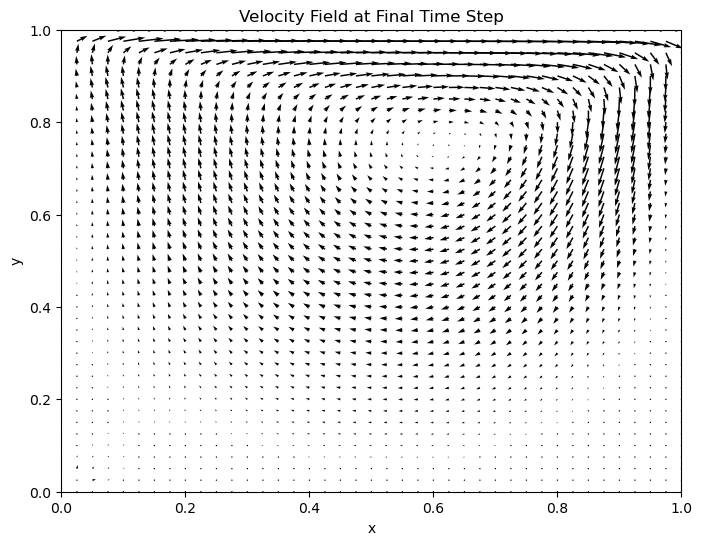

In [420]:
# Velocity Field Visualization

plt.figure(figsize=(8, 6))
plt.title("Velocity Field at Final Time Step")
plt.quiver(X, Y, u, v)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, L)
plt.ylim(0, L)
plt.show()

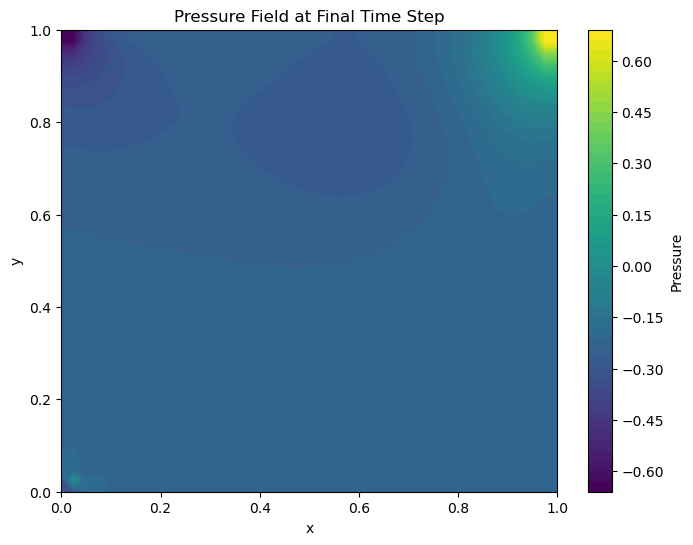

In [421]:
# Pressure Field Visualization
plt.figure(figsize=(8, 6))
plt.title("Pressure Field at Final Time Step")
plt.contourf(X, Y, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, L)
plt.ylim(0, L)
plt.show()

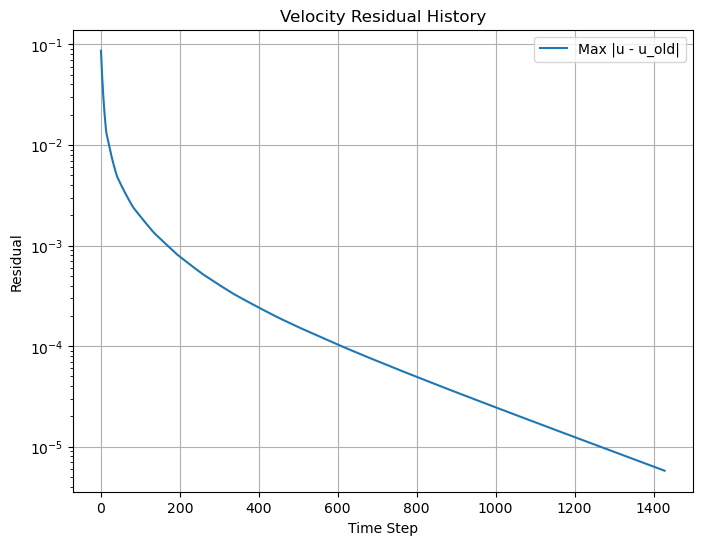

In [422]:
# Velocity Residual Plot
plt.figure(figsize=(8, 6))
plt.title("Velocity Residual History")
plt.semilogy(residual_history, label='Max |u - u_old|')
plt.xlabel('Time Step')
plt.ylabel('Residual')
plt.grid()
plt.legend()
plt.show()

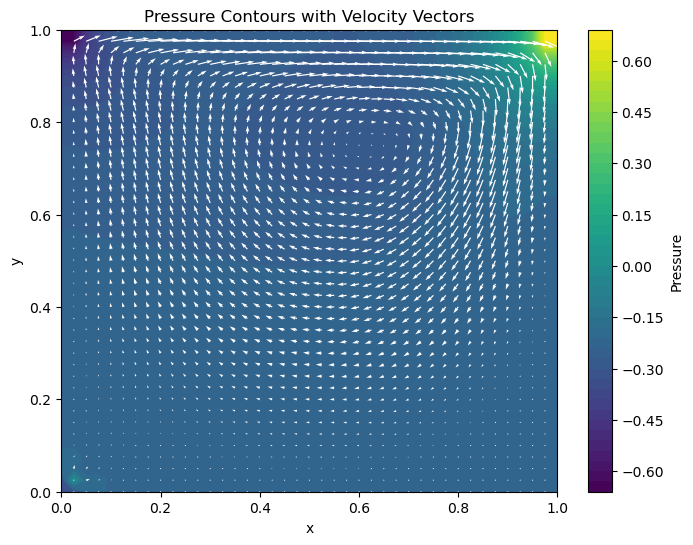

In [423]:
# Contour Plot of Pressure with a colormap and velocity vectors
plt.figure(figsize=(8, 6))
plt.title("Pressure Contours with Velocity Vectors")
plt.contourf(X, Y, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.quiver(X, Y, u, v, color='white', scale=10)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, L)
plt.ylim(0, L)
plt.show()